# 3. Comparação dos modelos

Este notebook executa o experimento comparativo definido no protocolo
de validação temporal.

Serão avaliados:

- Persistência;
- Regressão Linear;
- Regressão Ridge;
- Random Forest;
- Gradient Boosting.

Todos os modelos utilizam as mesmas variáveis preditoras do Cenário A,
o mesmo alvo e os mesmos períodos de teste.

## 3.1 Configuração

In [1]:
from pathlib import Path
import sys
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd()

while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "src").is_dir()
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Raiz do projeto: {PROJECT_ROOT}")

Raiz do projeto: /home/sara/Documentos/tcc-evasao-ensino-superior


In [3]:
from src.validation import criar_folds_temporais

from src.evaluation import (
    avaliar_persistencia,
    avaliar_modelo,
    criar_linear_regression,
    criar_ridge,
    criar_random_forest,
    criar_gradient_boosting
)

## 3.2 Carregamento da base processada

In [4]:
CAMINHO_BASE_PROCESSADA = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "base_modelo_uf.csv"
)

df_modelo_base = pd.read_csv(
    CAMINHO_BASE_PROCESSADA
)

print("Dimensões:", df_modelo_base.shape)

Dimensões: (189, 10)


In [5]:
df_modelo_base["ano_inicio"] = (
    df_modelo_base["ano_fluxo"]
    .str[:4]
    .astype(int)
)

## 3.3 Protocolos de validação

In [6]:
folds_expanding = criar_folds_temporais(
    df_modelo_base,
    estrategia="expanding",
    tamanho_treino=4
)

folds_rolling = criar_folds_temporais(
    df_modelo_base,
    estrategia="rolling",
    tamanho_treino=4
)

In [7]:
print("Expanding:")
display(pd.DataFrame(folds_expanding))

print("\nRolling:")
display(pd.DataFrame(folds_rolling))

Expanding:


,fold,periodos_treino,periodo_teste,n_treino,n_teste,ufs_treino,ufs_teste
0,1,"[2017, 2018, 2019, 2020]",2021,108,27,27,27
1,2,"[2017, 2018, 2019, 2020, 2021]",2022,135,27,27,27
2,3,"[2017, 2018, 2019, 2020, 2021, 2022]",2023,162,27,27,27



Rolling:


,fold,periodos_treino,periodo_teste,n_treino,n_teste,ufs_treino,ufs_teste
0,1,"[2017, 2018, 2019, 2020]",2021,108,27,27,27
1,2,"[2018, 2019, 2020, 2021]",2022,108,27,27,27
2,3,"[2019, 2020, 2021, 2022]",2023,108,27,27,27


## 3.4 Baseline — Persistência

In [8]:
resultados_persistencia_expanding, previsoes_persistencia_expanding, metricas_persistencia_expanding = (
    avaliar_persistencia(
        df_modelo_base,
        folds_expanding
    )
)

In [9]:
resultados_persistencia_expanding

,fold,periodo_teste,mae,rmse,r2,n_teste
0,1,2021,2.511111,2.782751,-0.493824,27
1,2,2022,1.555556,2.317566,-0.107975,27
2,3,2023,1.885185,2.448809,-0.348168,27


In [10]:
previsoes_persistencia_expanding

,uf,ano_fluxo,evasao_t,previsao,erro,erro_abs,fold
0,Acre,2021-2022,15.2,14.3,0.9,0.9,1
1,Alagoas,2021-2022,16.8,13.2,3.6,3.6,1
2,Amapá,2021-2022,18.0,15.7,2.3,2.3,1
3,Amazonas,2021-2022,16.1,13.5,2.6,2.6,1
4,Bahia,2021-2022,17.1,14.7,2.4,2.4,1
...,...,...,...,...,...,...,...
76,Roraima,2023-2024,19.1,21.9,-2.8,2.8,3
77,Santa Catarina,2023-2024,20.6,18.3,2.3,2.3,3
78,Sergipe,2023-2024,16.3,15.8,0.5,0.5,3
79,São Paulo,2023-2024,17.6,15.9,1.7,1.7,3


In [11]:
metricas_persistencia_expanding

{'mae': 1.9839506172839505,
 'rmse': 2.5239837216512497,
 'r2': -0.23992513603135524}

In [12]:
resultados_persistencia_rolling, previsoes_persistencia_rolling, metricas_persistencia_rolling = (
    avaliar_persistencia(
        df_modelo_base,
        folds_rolling
    )
)

In [13]:
resultados_persistencia_rolling

,fold,periodo_teste,mae,rmse,r2,n_teste
0,1,2021,2.511111,2.782751,-0.493824,27
1,2,2022,1.555556,2.317566,-0.107975,27
2,3,2023,1.885185,2.448809,-0.348168,27


In [14]:
previsoes_persistencia_rolling

,uf,ano_fluxo,evasao_t,previsao,erro,erro_abs,fold
0,Acre,2021-2022,15.2,14.3,0.9,0.9,1
1,Alagoas,2021-2022,16.8,13.2,3.6,3.6,1
2,Amapá,2021-2022,18.0,15.7,2.3,2.3,1
3,Amazonas,2021-2022,16.1,13.5,2.6,2.6,1
4,Bahia,2021-2022,17.1,14.7,2.4,2.4,1
...,...,...,...,...,...,...,...
76,Roraima,2023-2024,19.1,21.9,-2.8,2.8,3
77,Santa Catarina,2023-2024,20.6,18.3,2.3,2.3,3
78,Sergipe,2023-2024,16.3,15.8,0.5,0.5,3
79,São Paulo,2023-2024,17.6,15.9,1.7,1.7,3


In [15]:
metricas_persistencia_rolling

{'mae': 1.9839506172839505,
 'rmse': 2.5239837216512497,
 'r2': -0.23992513603135524}

## 3.5 Modelo 1 — Regressão Linear

In [16]:
resultados_lr_expanding, previsoes_lr_expanding, metricas_lr_expanding = (
    avaliar_modelo(
        df_modelo_base,
        folds_expanding,
        criar_linear_regression
    )
)

In [17]:
resultados_lr_rolling, previsoes_lr_rolling, metricas_lr_rolling = (
    avaliar_modelo(
        df_modelo_base,
        folds_rolling,
        criar_linear_regression
    )
)

## 3.6 Modelo 2 — Regressão Ridge

In [18]:
resultados_ridge_expanding, previsoes_ridge_expanding, metricas_ridge_expanding = (
    avaliar_modelo(
        df_modelo_base,
        folds_expanding,
        criar_ridge
    )
)

In [19]:
resultados_ridge_expanding

,fold,periodo_teste,mae,rmse,r2,n_treino,n_teste
0,1,2021,1.993244,2.445217,-0.153415,108,27
1,2,2022,1.163840,2.027672,0.151872,135,27
2,3,2023,1.589914,1.916327,0.174393,162,27


In [20]:
previsoes_ridge_expanding

,uf,ano_fluxo,evasao_t,previsao,erro,erro_abs,fold
0,Acre,2021-2022,15.2,15.167579,0.032421,0.032421,1
1,Alagoas,2021-2022,16.8,14.446218,2.353782,2.353782,1
2,Amapá,2021-2022,18.0,17.165132,0.834868,0.834868,1
3,Amazonas,2021-2022,16.1,14.891576,1.208424,1.208424,1
4,Bahia,2021-2022,17.1,15.177683,1.922317,1.922317,1
...,...,...,...,...,...,...,...
76,Roraima,2023-2024,19.1,20.962302,-1.862302,1.862302,3
77,Santa Catarina,2023-2024,20.6,18.321855,2.278145,2.278145,3
78,Sergipe,2023-2024,16.3,16.060694,0.239306,0.239306,3
79,São Paulo,2023-2024,17.6,16.132797,1.467203,1.467203,3


In [21]:
metricas_ridge_expanding

{'mae': 1.5823327216437657,
 'rmse': 2.1418723360708567,
 'r2': 0.1070862140205251}

In [22]:
resultados_ridge_rolling, previsoes_ridge_rolling, metricas_ridge_rolling = (
    avaliar_modelo(
        df_modelo_base,
        folds_rolling,
        criar_ridge
    )
)

In [23]:
resultados_ridge_rolling

,fold,periodo_teste,mae,rmse,r2,n_treino,n_teste
0,1,2021,1.993244,2.445217,-0.153415,108,27
1,2,2022,1.304655,1.936215,0.226655,108,27
2,3,2023,1.566215,1.905435,0.183751,108,27


In [24]:
previsoes_ridge_rolling

,uf,ano_fluxo,evasao_t,previsao,erro,erro_abs,fold
0,Acre,2021-2022,15.2,15.167579,0.032421,0.032421,1
1,Alagoas,2021-2022,16.8,14.446218,2.353782,2.353782,1
2,Amapá,2021-2022,18.0,17.165132,0.834868,0.834868,1
3,Amazonas,2021-2022,16.1,14.891576,1.208424,1.208424,1
4,Bahia,2021-2022,17.1,15.177683,1.922317,1.922317,1
...,...,...,...,...,...,...,...
76,Roraima,2023-2024,19.1,21.084561,-1.984561,1.984561,3
77,Santa Catarina,2023-2024,20.6,18.595746,2.004254,2.004254,3
78,Sergipe,2023-2024,16.3,16.297686,0.002314,0.002314,3
79,São Paulo,2023-2024,17.6,16.240180,1.359820,1.359820,3


In [25]:
metricas_ridge_rolling

{'mae': 1.6213713226066166,
 'rmse': 2.110189468165665,
 'r2': 0.1333070431281429}

## 3.7 Modelo 3 — Random Forest

In [26]:
resultados_rf_expanding, previsoes_rf_expanding, metricas_rf_expanding = (
    avaliar_modelo(
        df_modelo_base,
        folds_expanding,
        criar_random_forest
    )
)

In [27]:
resultados_rf_expanding

,fold,periodo_teste,mae,rmse,r2,n_treino,n_teste
0,1,2021,2.171726,2.605803,-0.309887,108,27
1,2,2022,1.514908,2.202727,-0.000892,135,27
2,3,2023,1.508478,2.053108,0.052329,162,27


In [28]:
previsoes_rf_expanding

,uf,ano_fluxo,evasao_t,previsao,erro,erro_abs,fold
0,Acre,2021-2022,15.2,14.969375,0.230625,0.230625,1
1,Alagoas,2021-2022,16.8,14.892777,1.907223,1.907223,1
2,Amapá,2021-2022,18.0,15.792806,2.207194,2.207194,1
3,Amazonas,2021-2022,16.1,14.922335,1.177665,1.177665,1
4,Bahia,2021-2022,17.1,15.190781,1.909219,1.909219,1
...,...,...,...,...,...,...,...
76,Roraima,2023-2024,19.1,19.028134,0.071866,0.071866,3
77,Santa Catarina,2023-2024,20.6,18.078585,2.521415,2.521415,3
78,Sergipe,2023-2024,16.3,16.742339,-0.442339,0.442339,3
79,São Paulo,2023-2024,17.6,15.925127,1.674873,1.674873,3


In [29]:
metricas_rf_expanding

{'mae': 1.7317041207689532,
 'rmse': 2.299091731599783,
 'r2': -0.028809495799273277}

In [30]:
resultados_rf_rolling, previsoes_rf_rolling, metricas_rf_rolling = (
    avaliar_modelo(
        df_modelo_base,
        folds_rolling,
        criar_random_forest
    )
)

In [31]:
resultados_rf_rolling

,fold,periodo_teste,mae,rmse,r2,n_treino,n_teste
0,1,2021,2.171726,2.605803,-0.309887,108,27
1,2,2022,1.426365,2.129563,0.064493,108,27
2,3,2023,1.543442,1.981969,0.116863,108,27


In [32]:
previsoes_rf_rolling

,uf,ano_fluxo,evasao_t,previsao,erro,erro_abs,fold
0,Acre,2021-2022,15.2,14.969375,0.230625,0.230625,1
1,Alagoas,2021-2022,16.8,14.892777,1.907223,1.907223,1
2,Amapá,2021-2022,18.0,15.792806,2.207194,2.207194,1
3,Amazonas,2021-2022,16.1,14.922335,1.177665,1.177665,1
4,Bahia,2021-2022,17.1,15.190781,1.909219,1.909219,1
...,...,...,...,...,...,...,...
76,Roraima,2023-2024,19.1,18.792474,0.307526,0.307526,3
77,Santa Catarina,2023-2024,20.6,17.899370,2.700630,2.700630,3
78,Sergipe,2023-2024,16.3,16.850601,-0.550601,0.550601,3
79,São Paulo,2023-2024,17.6,15.912437,1.687563,1.687563,3


In [33]:
metricas_rf_rolling

{'mae': 1.7138442148729198,
 'rmse': 2.2548800775060487,
 'r2': 0.010378176376825365}

## 3.8 Modelo 4 — Gradient Boosting

In [34]:
resultados_gb_expanding, previsoes_gb_expanding, metricas_gb_expanding = (
    avaliar_modelo(
        df_modelo_base,
        folds_expanding,
        criar_gradient_boosting
    )
)

In [35]:
resultados_gb_expanding

,fold,periodo_teste,mae,rmse,r2,n_treino,n_teste
0,1,2021,2.212677,2.656329,-0.361176,108,27
1,2,2022,1.749261,2.383779,-0.172190,135,27
2,3,2023,1.672773,2.149010,-0.038272,162,27


In [36]:
previsoes_gb_expanding

,uf,ano_fluxo,evasao_t,previsao,erro,erro_abs,fold
0,Acre,2021-2022,15.2,14.099966,1.100034,1.100034,1
1,Alagoas,2021-2022,16.8,15.176040,1.623960,1.623960,1
2,Amapá,2021-2022,18.0,16.692509,1.307491,1.307491,1
3,Amazonas,2021-2022,16.1,15.319339,0.780661,0.780661,1
4,Bahia,2021-2022,17.1,14.200202,2.899798,2.899798,1
...,...,...,...,...,...,...,...
76,Roraima,2023-2024,19.1,19.246858,-0.146858,0.146858,3
77,Santa Catarina,2023-2024,20.6,17.518839,3.081161,3.081161,3
78,Sergipe,2023-2024,16.3,16.854644,-0.554644,0.554644,3
79,São Paulo,2023-2024,17.6,15.561736,2.038264,2.038264,3


In [37]:
metricas_gb_expanding

{'mae': 1.8782367371447346,
 'rmse': 2.4053227621187974,
 'r2': -0.12607959051379458}

In [38]:
resultados_gb_rolling, previsoes_gb_rolling, metricas_gb_rolling = (
    avaliar_modelo(
        df_modelo_base,
        folds_rolling,
        criar_gradient_boosting
    )
)

In [39]:
resultados_gb_rolling

,fold,periodo_teste,mae,rmse,r2,n_treino,n_teste
0,1,2021,2.212677,2.656329,-0.361176,108,27
1,2,2022,1.638527,2.270173,-0.063123,108,27
2,3,2023,1.675323,2.095168,0.013103,108,27


In [40]:
previsoes_gb_rolling

,uf,ano_fluxo,evasao_t,previsao,erro,erro_abs,fold
0,Acre,2021-2022,15.2,14.099966,1.100034,1.100034,1
1,Alagoas,2021-2022,16.8,15.176040,1.623960,1.623960,1
2,Amapá,2021-2022,18.0,16.692509,1.307491,1.307491,1
3,Amazonas,2021-2022,16.1,15.319339,0.780661,0.780661,1
4,Bahia,2021-2022,17.1,14.200202,2.899798,2.899798,1
...,...,...,...,...,...,...,...
76,Roraima,2023-2024,19.1,19.458003,-0.358003,0.358003,3
77,Santa Catarina,2023-2024,20.6,17.229403,3.370597,3.370597,3
78,Sergipe,2023-2024,16.3,16.819013,-0.519013,0.519013,3
79,São Paulo,2023-2024,17.6,15.477731,2.122269,2.122269,3


In [41]:
metricas_gb_rolling

{'mae': 1.8421754466458544,
 'rmse': 2.352268259077998,
 'r2': -0.07695129217329666}

## 3.9 Comparação dos resultados

In [42]:
resultados_modelos = pd.DataFrame([
    # Persistência
    {
        "modelo": "Persistência",
        "protocolo": "Expanding",
        **metricas_persistencia_expanding
    },
    {
        "modelo": "Persistência",
        "protocolo": "Rolling",
        **metricas_persistencia_rolling
    },

    # Regressão Linear
    {
        "modelo": "Regressão Linear",
        "protocolo": "Expanding",
        **metricas_lr_expanding
    },
    {
        "modelo": "Regressão Linear",
        "protocolo": "Rolling",
        **metricas_lr_rolling
    },

    # Ridge
    {
        "modelo": "Ridge",
        "protocolo": "Expanding",
        **metricas_ridge_expanding
    },
    {
        "modelo": "Ridge",
        "protocolo": "Rolling",
        **metricas_ridge_rolling
    },

    # Random Forest
    {
        "modelo": "Random Forest",
        "protocolo": "Expanding",
        **metricas_rf_expanding
    },
    {
        "modelo": "Random Forest",
        "protocolo": "Rolling",
        **metricas_rf_rolling
    },

    # Gradient Boosting
    {
        "modelo": "Gradient Boosting",
        "protocolo": "Expanding",
        **metricas_gb_expanding
    },
    {
        "modelo": "Gradient Boosting",
        "protocolo": "Rolling",
        **metricas_gb_rolling
    }
])

resultados_modelos = resultados_modelos.rename(
    columns={
        "mae": "MAE",
        "rmse": "RMSE",
        "r2": "R2"
    }
)

resultados_modelos = resultados_modelos[
    [
        "modelo",
        "protocolo",
        "MAE",
        "RMSE",
        "R2"
    ]
].round(4)

resultados_modelos

,modelo,protocolo,MAE,RMSE,R2
0,Persistência,Expanding,1.9840,2.5240,-0.2399
1,Persistência,Rolling,1.9840,2.5240,-0.2399
2,Regressão Linear,Expanding,1.5891,2.1761,0.0783
3,Regressão Linear,Rolling,1.5988,2.1127,0.1312
4,Ridge,Expanding,1.5823,2.1419,0.1071
5,Ridge,Rolling,1.6214,2.1102,0.1333
6,Random Forest,Expanding,1.7317,2.2991,-0.0288
7,Random Forest,Rolling,1.7138,2.2549,0.0104
8,Gradient Boosting,Expanding,1.8782,2.4053,-0.1261
9,Gradient Boosting,Rolling,1.8422,2.3523,-0.0770


In [43]:
tabela_comparativa = (
    resultados_modelos
    .sort_values(
        ["protocolo", "MAE"]
    )
    .reset_index(drop=True)
)

tabela_comparativa

,modelo,protocolo,MAE,RMSE,R2
0,Ridge,Expanding,1.5823,2.1419,0.1071
1,Regressão Linear,Expanding,1.5891,2.1761,0.0783
2,Random Forest,Expanding,1.7317,2.2991,-0.0288
3,Gradient Boosting,Expanding,1.8782,2.4053,-0.1261
4,Persistência,Expanding,1.9840,2.5240,-0.2399
5,Regressão Linear,Rolling,1.5988,2.1127,0.1312
6,Ridge,Rolling,1.6214,2.1102,0.1333
7,Random Forest,Rolling,1.7138,2.2549,0.0104
8,Gradient Boosting,Rolling,1.8422,2.3523,-0.0770
9,Persistência,Rolling,1.9840,2.5240,-0.2399


## 3.10 Análise dos resultados por fold

In [44]:
resultados_por_fold = pd.concat(
    [
        resultados_persistencia_expanding.assign(
            modelo="Persistência",
            protocolo="Expanding"
        ),
        resultados_persistencia_rolling.assign(
            modelo="Persistência",
            protocolo="Rolling"
        ),
        resultados_lr_expanding.assign(
            modelo="Regressão Linear",
            protocolo="Expanding"
        ),
        resultados_lr_rolling.assign(
            modelo="Regressão Linear",
            protocolo="Rolling"
        ),
        resultados_ridge_expanding.assign(
            modelo="Ridge",
            protocolo="Expanding"
        ),
        resultados_ridge_rolling.assign(
            modelo="Ridge",
            protocolo="Rolling"
        ),
        resultados_rf_expanding.assign(
            modelo="Random Forest",
            protocolo="Expanding"
        ),
        resultados_rf_rolling.assign(
            modelo="Random Forest",
            protocolo="Rolling"
        ),
        resultados_gb_expanding.assign(
            modelo="Gradient Boosting",
            protocolo="Expanding"
        ),
        resultados_gb_rolling.assign(
            modelo="Gradient Boosting",
            protocolo="Rolling"
        )
    ],
    ignore_index=True
)

resultados_por_fold = resultados_por_fold[
    [
        "modelo",
        "protocolo",
        "fold",
        "periodo_teste",
        "mae",
        "rmse",
        "r2",
        "n_treino",
        "n_teste"
    ]
].sort_values(
    [
        "periodo_teste",
        "protocolo",
        "modelo"
    ]
).reset_index(drop=True)

resultados_por_fold

,modelo,protocolo,fold,periodo_teste,mae,rmse,r2,n_treino,n_teste
0,Gradient Boosting,Expanding,1,2021,2.212677,2.656329,-0.361176,108.0,27
1,Persistência,Expanding,1,2021,2.511111,2.782751,-0.493824,NaN,27
2,Random Forest,Expanding,1,2021,2.171726,2.605803,-0.309887,108.0,27
3,Regressão Linear,Expanding,1,2021,1.989701,2.460974,-0.168328,108.0,27
4,Ridge,Expanding,1,2021,1.993244,2.445217,-0.153415,108.0,27
5,Gradient Boosting,Rolling,1,2021,2.212677,2.656329,-0.361176,108.0,27
6,Persistência,Rolling,1,2021,2.511111,2.782751,-0.493824,NaN,27
7,Random Forest,Rolling,1,2021,2.171726,2.605803,-0.309887,108.0,27
8,Regressão Linear,Rolling,1,2021,1.989701,2.460974,-0.168328,108.0,27
9,Ridge,Rolling,1,2021,1.993244,2.445217,-0.153415,108.0,27


In [45]:
tabela_mae = (
    resultados_por_fold
    .pivot_table(
        index="periodo_teste",
        columns=["modelo", "protocolo"],
        values="mae"
    )
    .round(3)
)

tabela_mae

modelo        Gradient Boosting         Persistência         Random Forest  \
protocolo             Expanding Rolling    Expanding Rolling     Expanding   
periodo_teste                                                                
2021                      2.213   2.213        2.511   2.511         2.172   
2022                      1.749   1.639        1.556   1.556         1.515   
2023                      1.673   1.675        1.885   1.885         1.508   

modelo                Regressão Linear             Ridge          
protocolo     Rolling        Expanding Rolling Expanding Rolling  
periodo_teste                                                     
2021            2.172            1.990   1.990     1.993   1.993  
2022            1.426            1.203   1.249     1.164   1.305  
2023            1.543            1.575   1.558     1.590   1.566

In [46]:
tabela_rmse = (
    resultados_por_fold
    .pivot_table(
        index="periodo_teste",
        columns=["modelo", "protocolo"],
        values="rmse"
    )
    .round(3)
)

tabela_rmse

modelo        Gradient Boosting         Persistência         Random Forest  \
protocolo             Expanding Rolling    Expanding Rolling     Expanding   
periodo_teste                                                                
2021                      2.656   2.656        2.783   2.783         2.606   
2022                      2.384   2.270        2.318   2.318         2.203   
2023                      2.149   2.095        2.449   2.449         2.053   

modelo                Regressão Linear             Ridge          
protocolo     Rolling        Expanding Rolling Expanding Rolling  
periodo_teste                                                     
2021            2.606            2.461   2.461     2.445   2.445  
2022            2.130            2.131   1.948     2.028   1.936  
2023            1.982            1.899   1.882     1.916   1.905

In [47]:
tabela_r2 = (
    resultados_por_fold
    .pivot_table(
        index="periodo_teste",
        columns=["modelo", "protocolo"],
        values="r2"
    )
    .round(3)
)

tabela_r2

modelo        Gradient Boosting         Persistência         Random Forest  \
protocolo             Expanding Rolling    Expanding Rolling     Expanding   
periodo_teste                                                                
2021                     -0.361  -0.361       -0.494  -0.494        -0.310   
2022                     -0.172  -0.063       -0.108  -0.108        -0.001   
2023                     -0.038   0.013       -0.348  -0.348         0.052   

modelo                Regressão Linear             Ridge          
protocolo     Rolling        Expanding Rolling Expanding Rolling  
periodo_teste                                                     
2021           -0.310           -0.168  -0.168    -0.153  -0.153  
2022            0.064            0.063   0.218     0.152   0.227  
2023            0.117            0.189   0.204     0.174   0.184

In [48]:
estabilidade_mae = (
    resultados_por_fold
    .groupby(["modelo", "protocolo"])["mae"]
    .agg(
        media="mean",
        desvio_padrao="std",
        minimo="min",
        maximo="max"
    )
    .round(3)
    .reset_index()
)

estabilidade_mae

,modelo,protocolo,media,desvio_padrao,minimo,maximo
0,Gradient Boosting,Expanding,1.878,0.292,1.673,2.213
1,Gradient Boosting,Rolling,1.842,0.321,1.639,2.213
2,Persistência,Expanding,1.984,0.485,1.556,2.511
3,Persistência,Rolling,1.984,0.485,1.556,2.511
4,Random Forest,Expanding,1.732,0.381,1.508,2.172
5,Random Forest,Rolling,1.714,0.401,1.426,2.172
6,Regressão Linear,Expanding,1.589,0.394,1.203,1.990
7,Regressão Linear,Rolling,1.599,0.372,1.249,1.990
8,Ridge,Expanding,1.582,0.415,1.164,1.993
9,Ridge,Rolling,1.621,0.348,1.305,1.993


In [49]:
comparacao_ridge = pd.merge(
    resultados_persistencia_expanding[
        ["fold", "periodo_teste", "mae"]
    ].rename(
        columns={"mae": "mae_persistencia"}
    ),
    resultados_ridge_expanding[
        ["fold", "periodo_teste", "mae"]
    ].rename(
        columns={"mae": "mae_ridge"}
    ),
    on=["fold", "periodo_teste"]
)

comparacao_ridge["reducao_mae"] = (
    comparacao_ridge["mae_persistencia"]
    - comparacao_ridge["mae_ridge"]
)

comparacao_ridge["reducao_percentual"] = (
    comparacao_ridge["reducao_mae"]
    / comparacao_ridge["mae_persistencia"]
    * 100
)

comparacao_ridge.round(3)

,fold,periodo_teste,mae_persistencia,mae_ridge,reducao_mae,reducao_percentual
0,1,2021,2.511,1.993,0.518,20.623
1,2,2022,1.556,1.164,0.392,25.182
2,3,2023,1.885,1.590,0.295,15.663


In [50]:
def comparar_com_persistencia(
    resultados_modelo,
    resultados_persistencia
):
    comparacao = pd.merge(
        resultados_persistencia[
            ["fold", "periodo_teste", "mae"]
        ].rename(
            columns={"mae": "mae_persistencia"}
        ),
        resultados_modelo[
            ["fold", "periodo_teste", "mae"]
        ].rename(
            columns={"mae": "mae_modelo"}
        ),
        on=["fold", "periodo_teste"]
    )

    comparacao["reducao_mae"] = (
        comparacao["mae_persistencia"]
        - comparacao["mae_modelo"]
    )

    comparacao["reducao_percentual"] = (
        comparacao["reducao_mae"]
        / comparacao["mae_persistencia"]
        * 100
    )

    return comparacao.round(3)

In [51]:
comparacao_rf = comparar_com_persistencia(
    resultados_rf_expanding,
    resultados_persistencia_expanding
)

comparacao_gb = comparar_com_persistencia(
    resultados_gb_expanding,
    resultados_persistencia_expanding
)

comparacao_rf

,fold,periodo_teste,mae_persistencia,mae_modelo,reducao_mae,reducao_percentual
0,1,2021,2.511,2.172,0.339,13.515
1,2,2022,1.556,1.515,0.041,2.613
2,3,2023,1.885,1.508,0.377,19.982


In [52]:
comparacao_gb

,fold,periodo_teste,mae_persistencia,mae_modelo,reducao_mae,reducao_percentual
0,1,2021,2.511,2.213,0.298,11.885
1,2,2022,1.556,1.749,-0.194,-12.452
2,3,2023,1.885,1.673,0.212,11.267


In [53]:
comparacao_protocolos = (
    resultados_por_fold
    .pivot_table(
        index=["modelo", "periodo_teste"],
        columns="protocolo",
        values="mae"
    )
    .reset_index()
)

comparacao_protocolos["diferenca_rolling_menos_expanding"] = (
    comparacao_protocolos["Rolling"]
    - comparacao_protocolos["Expanding"]
)

comparacao_protocolos.round(3)

protocolo,modelo,periodo_teste,Expanding,Rolling,diferenca_rolling_menos_expanding
0,Gradient Boosting,2021,2.213,2.213,0.000
1,Gradient Boosting,2022,1.749,1.639,-0.111
2,Gradient Boosting,2023,1.673,1.675,0.003
3,Persistência,2021,2.511,2.511,0.000
4,Persistência,2022,1.556,1.556,0.000
5,Persistência,2023,1.885,1.885,0.000
6,Random Forest,2021,2.172,2.172,0.000
7,Random Forest,2022,1.515,1.426,-0.089
8,Random Forest,2023,1.508,1.543,0.035
9,Regressão Linear,2021,1.990,1.990,0.000


## 3.11 Análise dos erros

In [54]:
previsoes_ridge_expanding.sort_values(
    "erro_abs",
    ascending=False
).head(10)

,uf,ano_fluxo,evasao_t,previsao,erro,erro_abs,fold
45,Rio Grande do Norte,2022-2023,22.2,13.828452,8.371548,8.371548,2
21,Rondônia,2021-2022,21.5,14.728017,6.771983,6.771983,1
24,Sergipe,2021-2022,17.6,13.628835,3.971165,3.971165,1
72,Rio Grande do Norte,2023-2024,15.0,18.788324,-3.788324,3.788324,3
8,Goiás,2021-2022,18.4,14.726338,3.673662,3.673662,1
23,Santa Catarina,2021-2022,18.7,15.223256,3.476744,3.476744,1
46,Rio Grande do Sul,2022-2023,18.8,15.327661,3.472339,3.472339,2
65,Mato Grosso do Sul,2023-2024,20.1,16.758840,3.341160,3.341160,3
53,Tocantins,2022-2023,17.3,14.066637,3.233363,3.233363,2
61,Espírito Santo,2023-2024,19.2,16.009730,3.190270,3.190270,3


In [55]:
previsoes_ridge_expanding["erro"].describe()

count    81.000000
mean      0.995898
std       1.908075
min      -3.788324
25%      -0.128392
50%       0.858395
75%       2.144859
max       8.371548
Name: erro, dtype: float64

In [56]:
erro_ridge_periodo = (
    previsoes_ridge_expanding
    .groupby("ano_fluxo")["erro_abs"]
    .agg(
        media="mean",
        mediana="median",
        maior_erro="max"
    )
    .round(3)
)

erro_ridge_periodo

,media,mediana,maior_erro
ano_fluxo,,,
2021-2022,1.993,1.922,6.772
2022-2023,1.164,0.607,8.372
2023-2024,1.590,1.693,3.788


In [57]:
erros_expanding = (
    previsoes_persistencia_expanding[
        ["uf", "ano_fluxo", "previsao"]
    ]
    .rename(
        columns={"previsao": "previsao_persistencia"}
    )
    .merge(
        previsoes_lr_expanding[
            ["uf", "ano_fluxo", "previsao"]
        ].rename(
            columns={"previsao": "previsao_lr"}
        ),
        on=["uf", "ano_fluxo"]
    )
    .merge(
        previsoes_ridge_expanding[
            ["uf", "ano_fluxo", "previsao"]
        ].rename(
            columns={"previsao": "previsao_ridge"}
        ),
        on=["uf", "ano_fluxo"]
    )
    .merge(
        previsoes_rf_expanding[
            ["uf", "ano_fluxo", "previsao"]
        ].rename(
            columns={"previsao": "previsao_rf"}
        ),
        on=["uf", "ano_fluxo"]
    )
    .merge(
        previsoes_gb_expanding[
            ["uf", "ano_fluxo", "previsao"]
        ].rename(
            columns={"previsao": "previsao_gb"}
        ),
        on=["uf", "ano_fluxo"]
    )
)

In [58]:
erros_expanding = erros_expanding.merge(
    df_modelo_base[
        ["uf", "ano_fluxo", "evasao_t"]
    ],
    on=["uf", "ano_fluxo"]
)

In [59]:
for coluna in [
    "previsao_persistencia",
    "previsao_lr",
    "previsao_ridge",
    "previsao_rf",
    "previsao_gb"
]:
    nome_erro = coluna.replace(
        "previsao_",
        "erro_"
    )

    erros_expanding[nome_erro] = (
        erros_expanding["evasao_t"]
        - erros_expanding[coluna]
    )

    erros_expanding[f"{nome_erro}_abs"] = (
        erros_expanding[nome_erro].abs()
    )

In [60]:
erros_expanding["diferenca_ridge_rf"] = (
    erros_expanding["previsao_ridge"]
    - erros_expanding["previsao_rf"]
)

erros_expanding["diferenca_ridge_rf_abs"] = (
    erros_expanding["diferenca_ridge_rf"].abs()
)

erros_expanding.sort_values(
    "diferenca_ridge_rf_abs",
    ascending=False
).head(10)

,uf,ano_fluxo,previsao_persistencia,previsao_lr,previsao_ridge,previsao_rf,previsao_gb,evasao_t,erro_persistencia,erro_persistencia_abs,erro_lr,erro_lr_abs,erro_ridge,erro_ridge_abs,erro_rf,erro_rf_abs,erro_gb,erro_gb_abs,diferenca_ridge_rf,diferenca_ridge_rf_abs
72,Rio Grande do Norte,2023-2024,22.2,18.726578,18.788324,15.795272,16.912122,15.0,-7.2,7.2,-3.726578,3.726578,-3.788324,3.788324,-0.795272,0.795272,-1.912122,1.912122,2.993052,2.993052
48,Rondônia,2022-2023,21.5,19.025463,19.240390,16.310790,16.796271,18.9,-2.6,2.6,-0.125463,0.125463,-0.340390,0.340390,2.589210,2.589210,2.103729,2.103729,2.929600,2.929600
22,Roraima,2021-2022,18.8,18.220929,17.918796,15.092850,14.975981,19.4,0.6,0.6,1.179071,1.179071,1.481204,1.481204,4.307150,4.307150,4.424019,4.424019,2.825945,2.825945
49,Roraima,2022-2023,19.4,19.644524,19.470486,17.024896,16.986863,21.9,2.5,2.5,2.255476,2.255476,2.429514,2.429514,4.875104,4.875104,4.913137,4.913137,2.445590,2.445590
17,Piauí,2021-2022,13.5,14.012665,13.967087,16.145512,16.428172,12.0,-1.5,1.5,-2.012665,2.012665,-1.967087,1.967087,-4.145512,4.145512,-4.428172,4.428172,-2.178425,2.178425
76,Roraima,2023-2024,21.9,21.154159,20.962302,19.028134,19.246858,19.1,-2.8,2.8,-2.054159,2.054159,-1.862302,1.862302,0.071866,0.071866,-0.146858,0.146858,1.934168,1.934168
75,Rondônia,2023-2024,18.9,17.458454,17.460108,15.577351,16.384359,18.8,-0.1,0.1,1.341546,1.341546,1.339892,1.339892,3.222649,3.222649,2.415641,2.415641,1.882757,1.882757
46,Rio Grande do Sul,2022-2023,15.2,14.981923,15.327661,17.145409,16.597250,18.8,3.6,3.6,3.818077,3.818077,3.472339,3.472339,1.654591,1.654591,2.202750,2.202750,-1.817747,1.817747
55,Alagoas,2023-2024,15.7,15.451713,15.505960,17.210088,17.088687,17.3,1.6,1.6,1.848287,1.848287,1.794040,1.794040,0.089912,0.089912,0.211313,0.211313,-1.704128,1.704128
33,Distrito Federal,2022-2023,14.5,14.914911,15.138941,16.683420,16.607979,14.7,0.2,0.2,-0.214911,0.214911,-0.438941,0.438941,-1.983420,1.983420,-1.907979,1.907979,-1.544479,1.544479


In [61]:
erro_por_uf = (
    previsoes_ridge_expanding
    .groupby("uf")["erro_abs"]
    .agg(
        mae="mean",
        mediana="median",
        maior_erro="max"
    )
    .sort_values(
        "mae",
        ascending=False
    )
    .round(3)
)

erro_por_uf

,mae,mediana,maior_erro
uf,,,
Rio Grande do Norte,4.433,3.788,8.372
Rondônia,2.817,1.340,6.772
Tocantins,2.570,2.860,3.233
Mato Grosso do Sul,2.327,2.781,3.341
Goiás,2.312,3.148,3.674
Rio Grande do Sul,2.095,2.145,3.472
Santa Catarina,2.058,2.278,3.477
Espírito Santo,1.935,2.480,3.190
Roraima,1.924,1.862,2.430


In [62]:
# Monta uma tabela única com as previsões dos cinco métodos
erros_expanding = (
    previsoes_persistencia_expanding[
        ["uf", "ano_fluxo", "previsao"]
    ]
    .rename(
        columns={
            "previsao": "previsao_persistencia"
        }
    )
    .merge(
        previsoes_lr_expanding[
            ["uf", "ano_fluxo", "previsao"]
        ].rename(
            columns={
                "previsao": "previsao_lr"
            }
        ),
        on=["uf", "ano_fluxo"],
        how="inner"
    )
    .merge(
        previsoes_ridge_expanding[
            ["uf", "ano_fluxo", "previsao"]
        ].rename(
            columns={
                "previsao": "previsao_ridge"
            }
        ),
        on=["uf", "ano_fluxo"],
        how="inner"
    )
    .merge(
        previsoes_rf_expanding[
            ["uf", "ano_fluxo", "previsao"]
        ].rename(
            columns={
                "previsao": "previsao_rf"
            }
        ),
        on=["uf", "ano_fluxo"],
        how="inner"
    )
    .merge(
        previsoes_gb_expanding[
            ["uf", "ano_fluxo", "previsao"]
        ].rename(
            columns={
                "previsao": "previsao_gb"
            }
        ),
        on=["uf", "ano_fluxo"],
        how="inner"
    )
    .merge(
        df_modelo_base[
            ["uf", "ano_fluxo", "evasao_t"]
        ],
        on=["uf", "ano_fluxo"],
        how="inner"
    )
)

# Calcula erro com sinal e erro absoluto para cada método
for modelo in [
    "persistencia",
    "lr",
    "ridge",
    "rf",
    "gb"
]:
    erros_expanding[f"erro_{modelo}"] = (
        erros_expanding["evasao_t"]
        - erros_expanding[f"previsao_{modelo}"]
    )

    erros_expanding[f"erro_abs_{modelo}"] = (
        erros_expanding[f"erro_{modelo}"].abs()
    )

# Verificações
print(
    "Dimensões da tabela de erros:",
    erros_expanding.shape
)

print(
    "Colunas de erro:",
    [
        coluna
        for coluna in erros_expanding.columns
        if coluna.startswith("erro")
    ]
)

assert len(erros_expanding) == 81

print("Análise de erros construída com sucesso.")

Dimensões da tabela de erros: (81, 18)
Colunas de erro: ['erro_persistencia', 'erro_abs_persistencia', 'erro_lr', 'erro_abs_lr', 'erro_ridge', 'erro_abs_ridge', 'erro_rf', 'erro_abs_rf', 'erro_gb', 'erro_abs_gb']
Análise de erros construída com sucesso.


In [63]:
erros_expanding_resumo = erros_expanding[
    [
        "uf",
        "ano_fluxo",
        "evasao_t",

        "previsao_persistencia",
        "erro_persistencia",
        "erro_abs_persistencia",

        "previsao_lr",
        "erro_lr",
        "erro_abs_lr",

        "previsao_ridge",
        "erro_ridge",
        "erro_abs_ridge",

        "previsao_rf",
        "erro_rf",
        "erro_abs_rf",

        "previsao_gb",
        "erro_gb",
        "erro_abs_gb"
    ]
].copy()

erros_expanding_resumo.head()

,uf,ano_fluxo,evasao_t,previsao_persistencia,erro_persistencia,erro_abs_persistencia,previsao_lr,erro_lr,erro_abs_lr,previsao_ridge,erro_ridge,erro_abs_ridge,previsao_rf,erro_rf,erro_abs_rf,previsao_gb,erro_gb,erro_abs_gb
0,Acre,2021-2022,15.2,14.3,0.9,0.9,15.327113,-0.127113,0.127113,15.167579,0.032421,0.032421,14.969375,0.230625,0.230625,14.099966,1.100034,1.100034
1,Alagoas,2021-2022,16.8,13.2,3.6,3.6,14.497501,2.302499,2.302499,14.446218,2.353782,2.353782,14.892777,1.907223,1.907223,15.176040,1.623960,1.623960
2,Amapá,2021-2022,18.0,15.7,2.3,2.3,17.674654,0.325346,0.325346,17.165132,0.834868,0.834868,15.792806,2.207194,2.207194,16.692509,1.307491,1.307491
3,Amazonas,2021-2022,16.1,13.5,2.6,2.6,15.102840,0.997160,0.997160,14.891576,1.208424,1.208424,14.922335,1.177665,1.177665,15.319339,0.780661,0.780661
4,Bahia,2021-2022,17.1,14.7,2.4,2.4,15.292832,1.807168,1.807168,15.177683,1.922317,1.922317,15.190781,1.909219,1.909219,14.200202,2.899798,2.899798


In [64]:
colunas_erros = [
    "erro_abs_persistencia",
    "erro_abs_lr",
    "erro_abs_ridge",
    "erro_abs_rf",
    "erro_abs_gb"
]

erros_expanding_resumo["metodo_menor_erro"] = (
    erros_expanding_resumo[colunas_erros]
    .idxmin(axis=1)
    .str.replace(
        "erro_abs_",
        ""
    )
)

In [65]:
erros_expanding_resumo["metodo_menor_erro"].value_counts()

metodo_menor_erro
lr              22
persistencia    22
rf              16
ridge           12
gb               9
Name: count, dtype: int64

In [66]:
(
    erros_expanding_resumo
    .groupby(["ano_fluxo", "metodo_menor_erro"])
    .size()
    .unstack(fill_value=0)
)

metodo_menor_erro,gb,lr,persistencia,rf,ridge
ano_fluxo,,,,,
2021-2022,6,6,7,3,5
2022-2023,1,9,7,5,5
2023-2024,2,7,8,8,2


In [67]:
erros_expanding_resumo[
    ["evasao_t", "erro_abs_ridge"]
].corr()

,evasao_t,erro_abs_ridge
evasao_t,1.000000,0.465756
erro_abs_ridge,0.465756,1.000000


In [68]:
for modelo in [
    "persistencia",
    "lr",
    "ridge",
    "rf",
    "gb"
]:
    correlacao = erros_expanding_resumo[
        ["evasao_t", f"erro_abs_{modelo}"]
    ].corr().iloc[0, 1]

    print(
        f"{modelo}: {correlacao:.4f}"
    )

persistencia: 0.3336
lr: 0.4475
ridge: 0.4658
rf: 0.5319
gb: 0.5195


In [69]:
erros_expanding_resumo["faixa_evasao"] = pd.qcut(
    erros_expanding_resumo["evasao_t"],
    q=3,
    labels=[
        "Baixa",
        "Média",
        "Alta"
    ]
)

In [70]:
erros_por_faixa = (
    erros_expanding_resumo
    .groupby(
        "faixa_evasao",
        observed=False
    )[
        [
            "erro_abs_persistencia",
            "erro_abs_lr",
            "erro_abs_ridge",
            "erro_abs_rf",
            "erro_abs_gb"
        ]
    ]
    .mean()
    .round(3)
)

erros_por_faixa

,erro_abs_persistencia,erro_abs_lr,erro_abs_ridge,erro_abs_rf,erro_abs_gb
faixa_evasao,,,,,
Baixa,1.700,1.089,1.085,1.168,1.333
Média,1.775,1.227,1.192,1.107,1.362
Alta,2.504,2.499,2.519,2.990,3.001


In [71]:
erro_medio_por_faixa = (
    erros_expanding_resumo
    .groupby(
        "faixa_evasao",
        observed=False
    )[
        [
            "erro_persistencia",
            "erro_lr",
            "erro_ridge",
            "erro_rf",
            "erro_gb"
        ]
    ]
    .mean()
    .round(3)
)

erro_medio_por_faixa

,erro_persistencia,erro_lr,erro_ridge,erro_rf,erro_gb
faixa_evasao,,,,,
Baixa,0.315,-0.374,-0.424,-0.298,-0.500
Média,1.418,1.221,1.156,0.948,1.289
Alta,1.981,2.277,2.298,2.940,2.982


In [72]:
analise_faixas = (
    erros_expanding_resumo
    .groupby(
        "faixa_evasao",
        observed=False
    )[
        [
            "erro_persistencia",
            "erro_lr",
            "erro_ridge",
            "erro_rf",
            "erro_gb",
            "erro_abs_persistencia",
            "erro_abs_lr",
            "erro_abs_ridge",
            "erro_abs_rf",
            "erro_abs_gb"
        ]
    ]
    .mean()
    .round(3)
)

analise_faixas

,erro_persistencia,erro_lr,erro_ridge,erro_rf,erro_gb,erro_abs_persistencia,erro_abs_lr,erro_abs_ridge,erro_abs_rf,erro_abs_gb
faixa_evasao,,,,,,,,,,
Baixa,0.315,-0.374,-0.424,-0.298,-0.500,1.700,1.089,1.085,1.168,1.333
Média,1.418,1.221,1.156,0.948,1.289,1.775,1.227,1.192,1.107,1.362
Alta,1.981,2.277,2.298,2.940,2.982,2.504,2.499,2.519,2.990,3.001


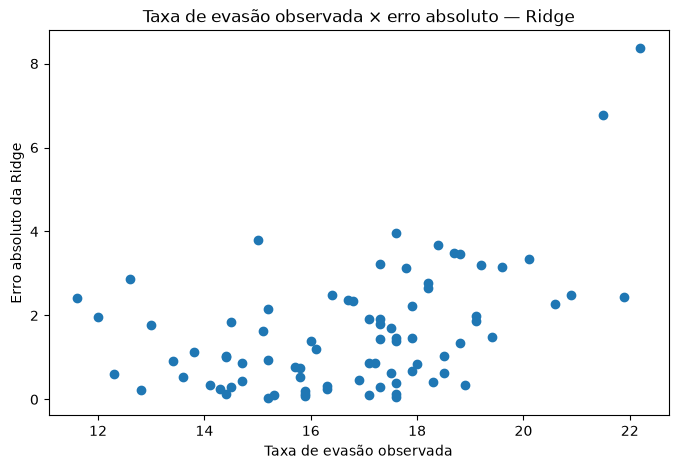

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    erros_expanding_resumo["evasao_t"],
    erros_expanding_resumo["erro_abs_ridge"]
)

plt.xlabel("Taxa de evasão observada")
plt.ylabel("Erro absoluto da Ridge")
plt.title("Taxa de evasão observada × erro absoluto — Ridge")
plt.show()

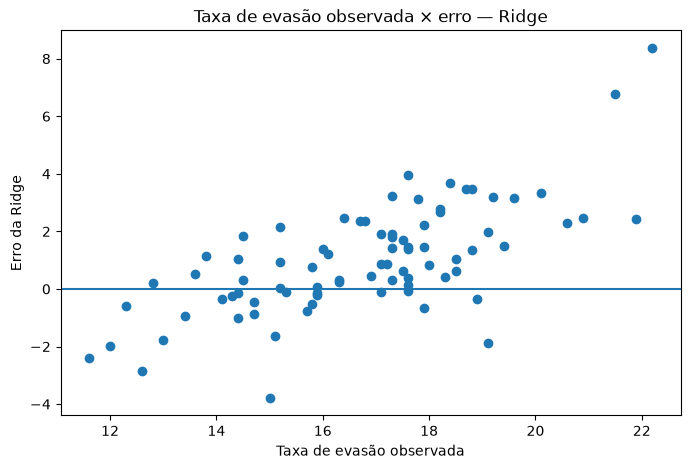

In [74]:
plt.figure(figsize=(8, 5))

plt.scatter(
    erros_expanding_resumo["evasao_t"],
    erros_expanding_resumo["erro_ridge"]
)

plt.axhline(0)

plt.xlabel("Taxa de evasão observada")
plt.ylabel("Erro da Ridge")
plt.title("Taxa de evasão observada × erro — Ridge")
plt.show()

In [75]:
def plotar_erros_modelo(
    df,
    coluna_erro,
    coluna_erro_abs,
    nome_modelo
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    axes[0].scatter(
        df["evasao_t"],
        df[coluna_erro_abs]
    )

    axes[0].set_xlabel(
        "Taxa de evasão observada"
    )
    axes[0].set_ylabel(
        f"Erro absoluto — {nome_modelo}"
    )
    axes[0].set_title(
        f"Taxa de evasão observada × erro absoluto — {nome_modelo}"
    )

    axes[1].scatter(
        df["evasao_t"],
        df[coluna_erro]
    )

    axes[1].axhline(
        0,
        linestyle="--"
    )

    axes[1].set_xlabel(
        "Taxa de evasão observada"
    )
    axes[1].set_ylabel(
        f"Erro — {nome_modelo}"
    )
    axes[1].set_title(
        f"Taxa de evasão observada × erro — {nome_modelo}"
    )

    plt.tight_layout()
    plt.show()

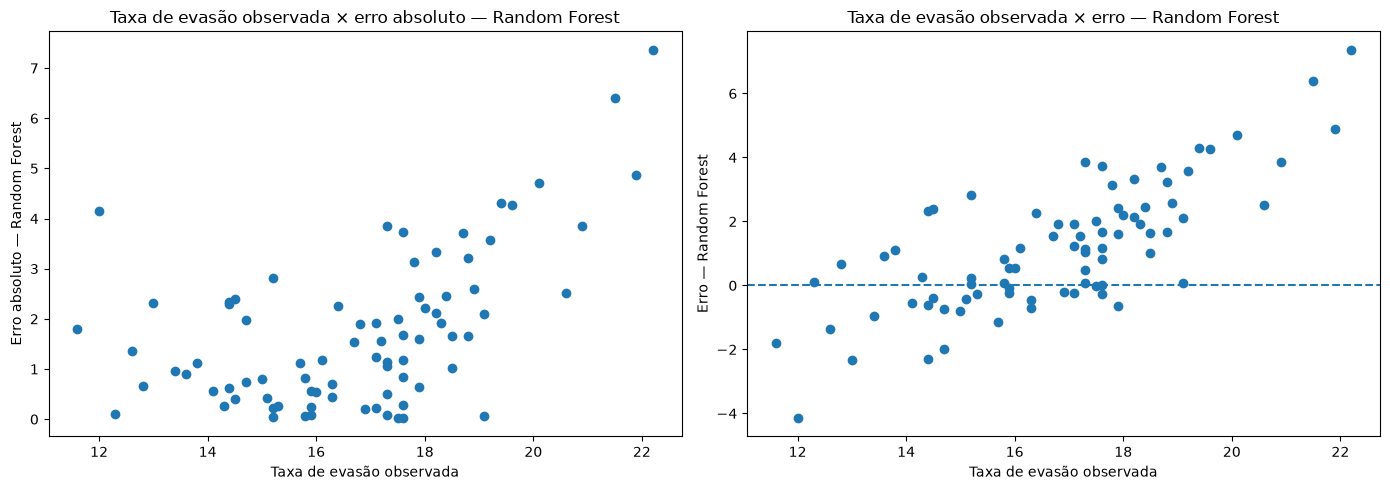

In [76]:
plotar_erros_modelo(
    erros_expanding_resumo,
    "erro_rf",
    "erro_abs_rf",
    "Random Forest"
)

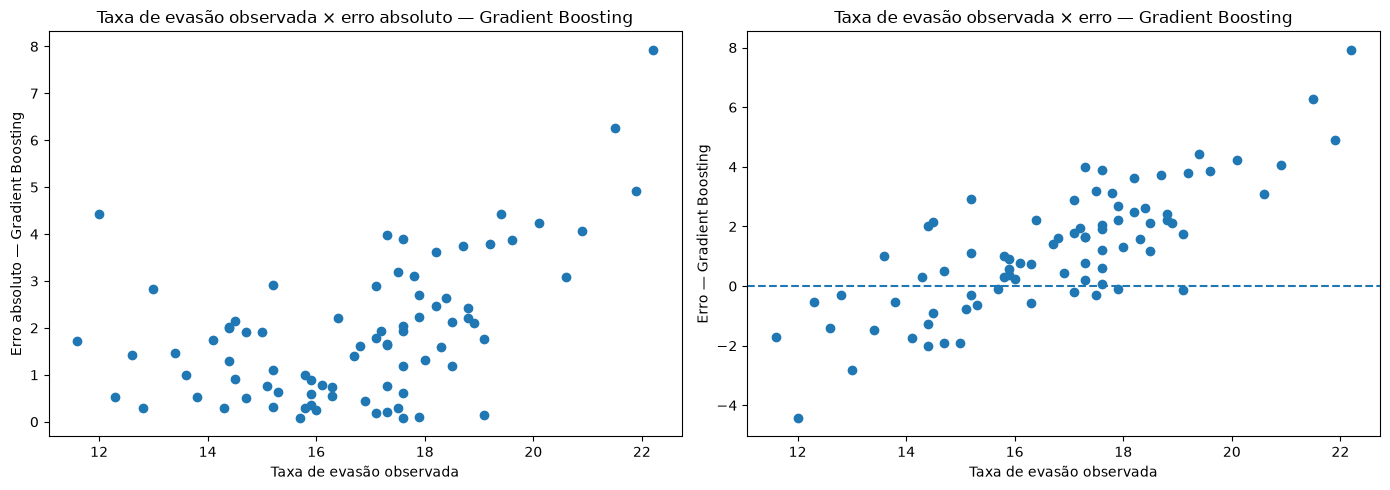

In [77]:
plotar_erros_modelo(
    erros_expanding_resumo,
    "erro_gb",
    "erro_abs_gb",
    "Gradient Boosting"
)

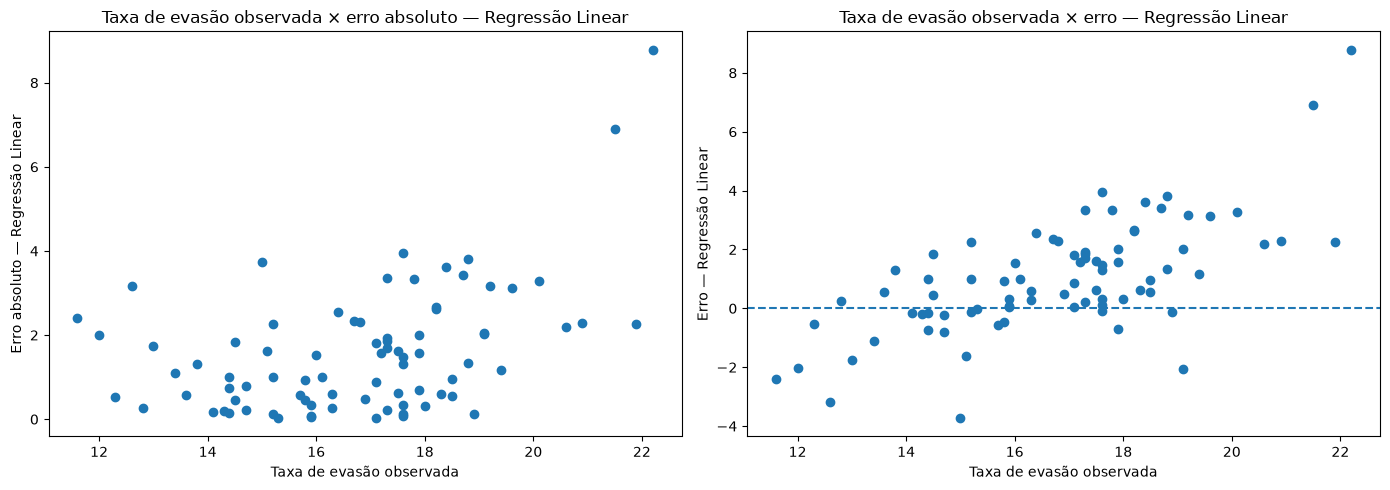

In [78]:
plotar_erros_modelo(
    erros_expanding_resumo,
    "erro_lr",
    "erro_abs_lr",
    "Regressão Linear"
)

In [79]:
import numpy as np

coef_ridge = np.polyfit(
    erros_expanding_resumo["evasao_t"],
    erros_expanding_resumo["erro_ridge"],
    1
)

coef_ridge

array([ 0.57501883, -8.63460212])

In [80]:
from sklearn.linear_model import LinearRegression

In [81]:
def analisar_calibracao(df, coluna_previsao, nome_modelo):
    X = df[[coluna_previsao]]
    y = df["evasao_t"]

    modelo_calibracao = LinearRegression()
    modelo_calibracao.fit(X, y)

    return {
        "modelo": nome_modelo,
        "intercepto": modelo_calibracao.intercept_,
        "inclinação": modelo_calibracao.coef_[0],
        "r2": modelo_calibracao.score(X, y)
    }

In [82]:
calibracao = pd.DataFrame([
    analisar_calibracao(
        erros_expanding_resumo,
        "previsao_persistencia",
        "Persistência"
    ),
    analisar_calibracao(
        erros_expanding_resumo,
        "previsao_lr",
        "Regressão Linear"
    ),
    analisar_calibracao(
        erros_expanding_resumo,
        "previsao_ridge",
        "Ridge"
    ),
    analisar_calibracao(
        erros_expanding_resumo,
        "previsao_rf",
        "Random Forest"
    ),
    analisar_calibracao(
        erros_expanding_resumo,
        "previsao_gb",
        "Gradient Boosting"
    )
])

calibracao.round(3)

,modelo,intercepto,inclinação,r2
0,Persistência,8.635,0.523,0.329
1,Regressão Linear,5.032,0.745,0.322
2,Ridge,4.573,0.773,0.328
3,Random Forest,4.642,0.777,0.260
4,Gradient Boosting,5.397,0.732,0.198


Com o histórico agregado dos indicadores, os resultados deste experimento serão interpretados considerando simultaneamente desempenho agregado, variação temporal entre os folds e comportamento dos erros.

## 3.12 Exportação dos resultados do Cenário A

In [83]:
CAMINHO_RESULTADOS_A = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resultados_cenario_a.csv"
)

CAMINHO_RESULTADOS_A.parent.mkdir(
    parents=True,
    exist_ok=True
)

resultados_modelos.to_csv(
    CAMINHO_RESULTADOS_A,
    index=False
)

print(
    f"Resultados do Cenário A salvos em:\n{CAMINHO_RESULTADOS_A}"
)

Resultados do Cenário A salvos em:
/home/sara/Documentos/tcc-evasao-ensino-superior/results/tables/resultados_cenario_a.csv


## 3.13 Exportação dos resultados por fold

In [84]:
CAMINHO_FOLDS_A = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resultados_por_fold_cenario_a.csv"
)

resultados_por_fold.to_csv(
    CAMINHO_FOLDS_A,
    index=False
)

print(
    f"Resultados por fold do Cenário A salvos em:\n"
    f"{CAMINHO_FOLDS_A}"
)

Resultados por fold do Cenário A salvos em:
/home/sara/Documentos/tcc-evasao-ensino-superior/results/tables/resultados_por_fold_cenario_a.csv


## 3.14 Exportação das previsões do Gradient Boosting

In [85]:
CAMINHO_PREVISOES_GB_A = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "previsoes_gb_cenario_a_expanding.csv"
)

previsoes_gb_expanding.to_csv(
    CAMINHO_PREVISOES_GB_A,
    index=False
)

print(
    f"Previsões do Gradient Boosting — Cenário A salvas em:\n"
    f"{CAMINHO_PREVISOES_GB_A}"
)

Previsões do Gradient Boosting — Cenário A salvas em:
/home/sara/Documentos/tcc-evasao-ensino-superior/results/tables/previsoes_gb_cenario_a_expanding.csv


In [86]:
erros_expanding_resumo.shape

(81, 20)

In [87]:
erros_expanding_resumo.columns.tolist()

['uf',
 'ano_fluxo',
 'evasao_t',
 'previsao_persistencia',
 'erro_persistencia',
 'erro_abs_persistencia',
 'previsao_lr',
 'erro_lr',
 'erro_abs_lr',
 'previsao_ridge',
 'erro_ridge',
 'erro_abs_ridge',
 'previsao_rf',
 'erro_rf',
 'erro_abs_rf',
 'previsao_gb',
 'erro_gb',
 'erro_abs_gb',
 'metodo_menor_erro',
 'faixa_evasao']

In [88]:
erros_expanding_resumo.sort_values(
    "erro_abs_ridge",
    ascending=False
).head(10)

,uf,ano_fluxo,evasao_t,previsao_persistencia,erro_persistencia,erro_abs_persistencia,previsao_lr,erro_lr,erro_abs_lr,previsao_ridge,erro_ridge,erro_abs_ridge,previsao_rf,erro_rf,erro_abs_rf,previsao_gb,erro_gb,erro_abs_gb,metodo_menor_erro,faixa_evasao
45,Rio Grande do Norte,2022-2023,22.2,13.8,8.4,8.4,13.416004,8.783996,8.783996,13.828452,8.371548,8.371548,14.834193,7.365807,7.365807,14.270825,7.929175,7.929175,rf,Alta
21,Rondônia,2021-2022,21.5,15.7,5.8,5.8,14.593260,6.906740,6.906740,14.728017,6.771983,6.771983,15.104327,6.395673,6.395673,15.229546,6.270454,6.270454,persistencia,Alta
24,Sergipe,2021-2022,17.6,12.7,4.9,4.9,13.656541,3.943459,3.943459,13.628835,3.971165,3.971165,13.859569,3.740431,3.740431,13.712531,3.887469,3.887469,rf,Média
72,Rio Grande do Norte,2023-2024,15.0,22.2,-7.2,7.2,18.726578,-3.726578,3.726578,18.788324,-3.788324,3.788324,15.795272,-0.795272,0.795272,16.912122,-1.912122,1.912122,rf,Baixa
8,Goiás,2021-2022,18.4,15.1,3.3,3.3,14.785960,3.614040,3.614040,14.726338,3.673662,3.673662,15.938460,2.461540,2.461540,15.767292,2.632708,2.632708,rf,Alta
23,Santa Catarina,2021-2022,18.7,15.2,3.5,3.5,15.277476,3.422524,3.422524,15.223256,3.476744,3.476744,14.985915,3.714085,3.714085,14.961460,3.738540,3.738540,lr,Alta
46,Rio Grande do Sul,2022-2023,18.8,15.2,3.6,3.6,14.981923,3.818077,3.818077,15.327661,3.472339,3.472339,17.145409,1.654591,1.654591,16.597250,2.202750,2.202750,rf,Alta
65,Mato Grosso do Sul,2023-2024,20.1,17.2,2.9,2.9,16.819735,3.280265,3.280265,16.758840,3.341160,3.341160,15.396996,4.703004,4.703004,15.863479,4.236521,4.236521,persistencia,Alta
53,Tocantins,2022-2023,17.3,12.6,4.7,4.7,13.945772,3.354228,3.354228,14.066637,3.233363,3.233363,13.452039,3.847961,3.847961,13.310194,3.989806,3.989806,ridge,Média
61,Espírito Santo,2023-2024,19.2,15.9,3.3,3.3,16.038417,3.161583,3.161583,16.009730,3.190270,3.190270,15.624852,3.575148,3.575148,15.404733,3.795267,3.795267,lr,Alta


In [89]:
erros_expanding_resumo[
    ["evasao_t", "erro_abs_ridge"]
].corr()

,evasao_t,erro_abs_ridge
evasao_t,1.000000,0.465756
erro_abs_ridge,0.465756,1.000000
